Affichage des plats selon l'apparittion légumes.

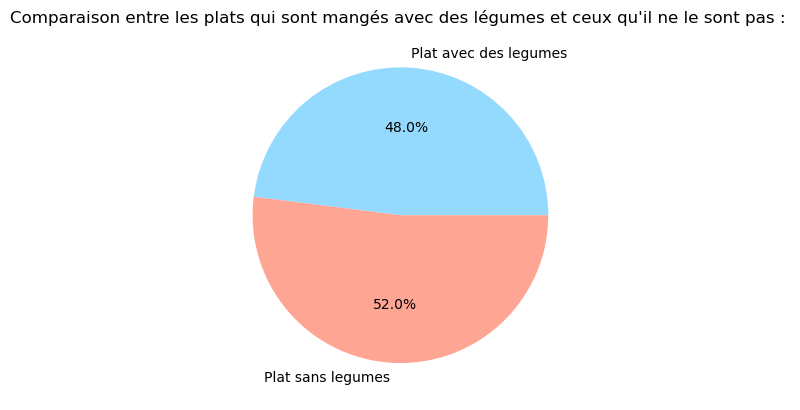

In [2]:
import pandas as pa
import matplotlib.pyplot as plt
import numpy as np

Plat = pa.read_csv("./Plat.csv")
Plat_Legume = Plat.loc[(Plat["legume_id"].notna())].shape[0]
Plat_Sans_Legume = Plat.loc[(Plat["legume_id"].isna())].shape[0]
couleurs = ["#94daff", "#ffa594"]

labels = ["Plat avec des legumes", "Plat sans legumes"]
tailles = [Plat_Legume, Plat_Sans_Legume]

plt.close()
plt.pie(tailles, labels = labels, autopct = lambda z : str(round(z, 2)) + '%', pctdistance = 0.6, colors = couleurs)
plt.title("Comparaison entre les plats qui sont mangés avec des légumes et ceux qu'il ne le sont pas : ")
plt.show()

On constate sur le graphe ci-dessus, que la majorité des plats ne sont pas mangés avec des légumes.
En effet, les Tenracs ne sont pas obligés d'inclure un légume dans leur plats sous risque de nuire à leur croyance, conviction ou bien santé.

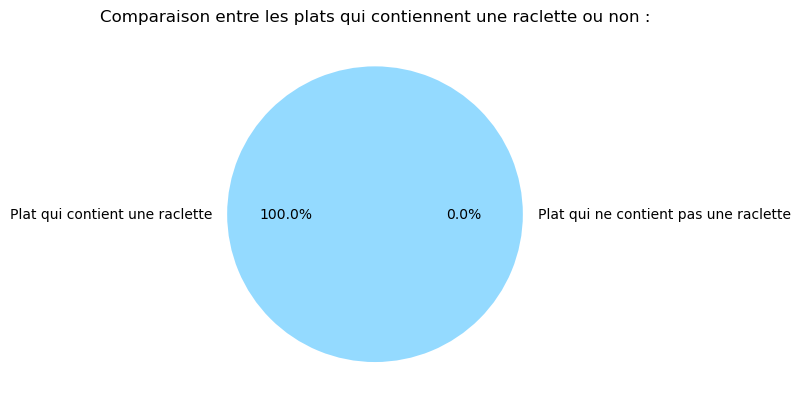

In [3]:
import pandas as pa
import matplotlib.pyplot as plt
import numpy as np

Plat = pa.read_csv("./Plat.csv")
Plat_raclette = Plat.loc[(Plat["raclette_id"].notna())].shape[0]
Plat_Sans_raclette = Plat.loc[(Plat["raclette_id"].isna())].shape[0]
couleurs = ["#94daff", "#ffa594"]

labels = ["Plat qui contient une raclette", "Plat qui ne contient pas une raclette"]
tailles = [Plat_raclette, Plat_Sans_raclette]

plt.close()
plt.pie(tailles, labels = labels, autopct = lambda z : str(round(z, 2)) + '%', pctdistance = 0.6, colors = couleurs)
plt.title("Comparaison entre les plats qui contiennent une raclette ou non :")
plt.show()

Alors qu'ici, on remarque que la totalité des plats sont composé d'une raclette due au fait que les tenracs adorent ajouter de la raclette dans leur plats.

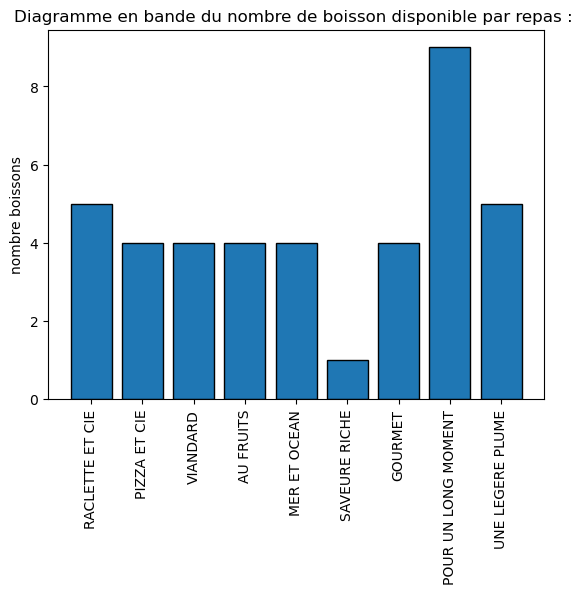

In [27]:
import pandas as pa
import matplotlib.pyplot as plt
import numpy as np

Repas = pa.read_csv("./Repas.csv")
Boisson = pa.read_csv("./Boisson.csv")
Repas_Servi_Avec = pa.read_csv("./Repas_Servi_Avec.csv")

compteur = Repas_Servi_Avec.groupby('repas_id').size().reset_index(name='nb_boissons')
resultat = pa.merge(compteur, Repas, on = "repas_id")

plt.close()
plt.bar(resultat["repas_nom"], resultat["nb_boissons"], edgecolor = "black")
plt.title("Diagramme en bande du nombre de boisson disponible par repas : ")
plt.xticks(rotation = 90)
plt.ylabel("nombre boissons")
plt.show()

On peut dire suite au graphe présent ci-dessus, que les plats dans la catégorie de repas "SAVEURE-RICHE" ne prend pas en compte qu'une seul boisson alors que les plats dans la catégorie de repas "POUR UN LONG MOMENT", prend en compte toutes les boissons car cette catégorie propose des plats très lourd mais aussi qui prennent du temps pour être mangé. Il faut alors plusieurs boissons différente à disposition des Tenracs pour satisfaire leur gosier.  

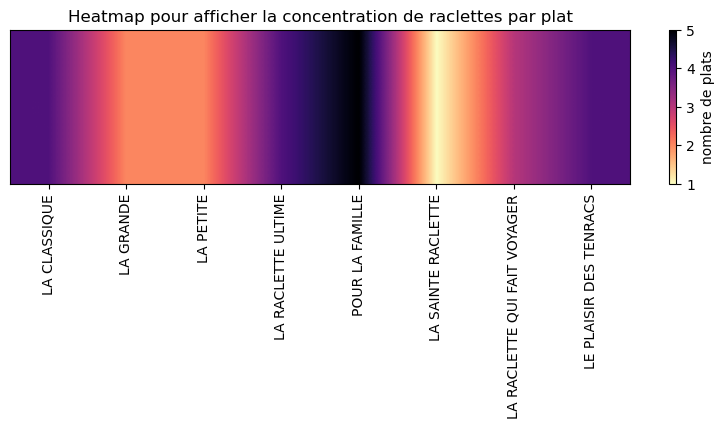

In [68]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import plotly.express as px

Plat = pa.read_csv("./Plat.csv")
Raclette = pa.read_csv("./Raclette.csv")

compteur = Plat.groupby('raclette_id').size().reset_index(name='nb_plat')
resultat = pa.merge(compteur, Raclette, on = 'raclette_id')

raclette_nom = resultat["raclette_nom"]
nb_plats = resultat["nb_plat"].values.reshape(1, -1) # imshow autorise seulement les valeurs sur une seul ligne

# Affichage aevc imshow
plt.figure(figsize = (10, 2))
plt.imshow(nb_plats, cmap = 'magma_r', aspect = 'auto', interpolation = 'bilinear', origin = 'lower') # cmap = colormap -> on prend le type magma_r (reverse), origin -> où placer le 0
# aspect = 'auto' --> met une taille automatique
# interpolation = 'bilinear' --> fait l'aspect dégradé

# Ajout d'une barre de légende / configuration des axes
plt.colorbar(label = "nombre de plats")
plt.yticks([]) # --> On cache l'axe des ordonnées car on a qu'une seul ligne
plt.xticks(range(len(raclette_nom)), resultat["raclette_nom"], rotation = 90) # len(plat) -> compte le nombre de plat, range -> place les noms de la liste sur chaque colonne du graphique
plt.title("Heatmap pour afficher la concentration de raclettes par plat")
plt.show()

On constate grâce au graphique "Heatmap", la concentration de plat (le nombre de plat) pour chaque raclettes.
Autrement dit, on constate qu'un seul plat est disponible pour la raclette "LA SAINTE RACLETTE" alors que d'autre raclette comme par exemple "LA GRANDE" ou bien "LA PETITE" est disponible pour au moins 3 plats différents.

On constate également que la raclette qui est le plus disponible dans le restaurant est la raclette "POUR LA FAMILLE".